In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [2]:
print(os.listdir('Vehicles/'))

['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']


In [3]:
image = cv2.imread('Vehicles/Motorcycles/Motorcycle (239).jpg')

In [4]:
image.shape

(183, 275, 3)

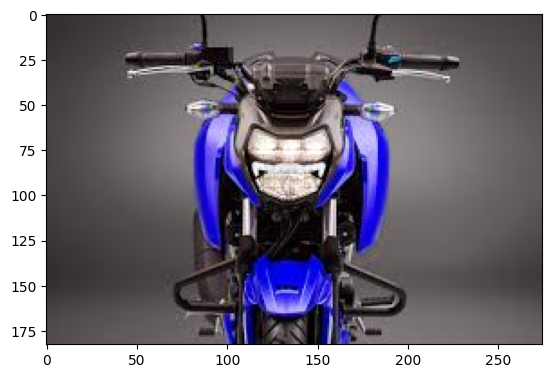

In [5]:
plt.imshow(image)

In [6]:
from sklearn.utils import shuffle
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [7]:
labels = {
    'Auto Rickshaws': 0,
    'Bikes': 1,
    'Cars': 2,
    'Motorcycles': 3,
    'Planes': 4,
    'Ships': 5,
    'Trains': 6
}

In [9]:
X = []
y = []

for i in os.listdir('Vehicles/'):
    for j in os.listdir(f'Vehicles/{i}'):
        if j.endswith(('.jpg', '.jpeg', '.png')):
            try:
                img = cv2.imread(f'Vehicles/{i}/{j}')
                img = cv2.resize(img, (224, 224))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = preprocess_input(img)
                X.append(img)
                y.append(labels[i])
            except:
                print(j)

X = np.array(X)
y = np.array(y)

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train.shape

(4403, 224, 224, 3)

In [13]:
X_test.shape

(1101, 224, 224, 3)

In [14]:
y_train.shape

(4403,)

In [15]:
y_test.shape

(1101,)

In [16]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

In [17]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [18]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    batch_size=32,
    epochs=15
)

Epoch 1/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 34s 219ms/step - accuracy: 0.9360 - loss: 0.3300 - val_accuracy: 0.9864 - val_loss: 0.0697
Epoch 2/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 29s 210ms/step - accuracy: 0.9886 - loss: 0.0613 - val_accuracy: 0.9900 - val_loss: 0.0433
Epoch 3/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 29s 210ms/step - accuracy: 0.9927 - loss: 0.0416 - val_accuracy: 0.9909 - val_loss: 0.0342
Epoch 4/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 29s 209ms/step - accuracy: 0.9927 - loss: 0.0291 - val_accuracy: 0.9927 - val_loss: 0.0318
Epoch 5/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 29s 209ms/step - accuracy: 0.9955 - loss: 0.0242 - val_accuracy: 0.9946 - val_loss: 0.0274
Epoch 6/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 29s 209ms/step - accuracy: 0.9968 - loss: 0.0186 - val_accuracy: 0.9955 - val_loss: 0.0254
Epoch 7/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 29s 209ms/step - accuracy: 0.9973 - loss: 0.0155 - val_accuracy: 0.9936 - val_loss: 0.0242
Epoch 8/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 29s 209ms/step - accuracy: 0.9980 - loss: 0

In [19]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64
)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 40s 513ms/step - accuracy: 0.9827 - loss: 0.0837 - val_accuracy: 0.9936 - val_loss: 0.0250
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 34s 497ms/step - accuracy: 0.9882 - loss: 0.0622 - val_accuracy: 0.9927 - val_loss: 0.0315
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 34s 498ms/step - accuracy: 0.9884 - loss: 0.0542 - val_accuracy: 0.9909 - val_loss: 0.0355
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 35s 507ms/step - accuracy: 0.9907 - loss: 0.0450 - val_accuracy: 0.9891 - val_loss: 0.0370
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 34s 497ms/step - accuracy: 0.9945 - loss: 0.0352 - val_accuracy: 0.9891 - val_loss: 0.0371
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 35s 502ms/step - accuracy: 0.9943 - loss: 0.0327 - val_accuracy: 0.9891 - val_loss: 0.0364
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 35s 502ms/step - accuracy: 0.9943 - loss: 0.0305 - val_accuracy: 0.9891 - val_loss: 0.0353
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 34s 497ms/step - accuracy: 0.9959 - loss: 0.0249 - val_accu

In [20]:
new_labels = {
    0: 'Auto Rickshaws',
    1: 'Bikes',
    2: 'Cars',
    3: 'Motorcycles',
    4: 'Planes',
    5: 'Ships',
    6: 'Trains'
}

In [23]:
img = cv2.imread('Train.jpg')
img = cv2.resize(img, (224, 224))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = preprocess_input(img)
img = img.reshape(1, 224, 224, 3)
pred = model.predict(img)

print(new_labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 825ms/step
Trains


In [24]:
img = cv2.imread('BYD.jpg')
img = cv2.resize(img, (180, 180))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = preprocess_input(img)
img = img.reshape(1, 180, 180, 3)
pred = model.predict(img)

print(new_labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step
Cars


In [25]:
img = cv2.imread('Tu_ara.jpg')
img = cv2.resize(img, (180, 180))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = preprocess_input(img)
img = img.reshape(1, 180, 180, 3)
pred = model.predict(img)

print(new_labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Auto Rickshaws


In [26]:
img = cv2.imread('Cybertruck.jpg')
img = cv2.resize(img, (180, 180))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = preprocess_input(img)
img = img.reshape(1, 180, 180, 3)
pred = model.predict(img)

print(new_labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Cars


In [27]:
img = cv2.imread('Moto.jpg')
img = cv2.resize(img, (180, 180))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = preprocess_input(img)
img = img.reshape(1, 180, 180, 3)
pred = model.predict(img)

print(new_labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Motorcycles
